# A calculator the model has to call

`08` made `numeric_acc` 1.000 by printing the three answers into the prompt. That was never a
capability. The harness did the arithmetic and the task became a different task, which `08`
said itself: "what a calculator tool would have achieved, minus the tool-call protocol and minus
the extraction step". Everything from `08` to `11` stands on it. This notebook withdraws it and
puts both missing pieces back.

**The prompt does not change.** System and user turns are v2's, byte for byte -- the Step 1
formulas, the demand to compute, the closing. Nothing is precomputed. A calculator is offered
through Qwen3's own `<tool_call>` protocol, and the only text that adds is the tool declaration
the chat template writes into the system turn. Nothing in the prompt says to use it.

**What is taught, and from where.** The raw Qwen3-1.7B -- no adapter from `09`, `10` or `11` --
is supervised on the three calls and nothing else: 245 tokens an example, no answer value, no
flag, no label. `10`'s dead labels are left for later, so the ceiling `10` measured still
applies to everything below.

**Gates, named before each run.**

| | run | bar | result |
| --- | --- | --- | --- |
| G0 | CPU | prompt identical to v2; gold calls reproduce the key; one token layout | pass |
| G1 | raw model + calculator | none -- the before | `numeric_acc` 0.067 |
| G2 | the tool seed | tool use >= 0.95, errors <= 0.02, `numeric_acc` >= 0.95 | **pass, 0.997** |
| G3 | 40 PPO steps, twice | numeric >= 0.90 every step and >= 0.95 every eval; tool use >= 0.95; critic above a clock over steps 20-39 | see below |

**The result.** The arithmetic works, and the model is the one doing it: 600 of 600 held-out
calls are the gold expression character for character, and held-out `numeric_acc` stays at
0.993-1.000 through both PPO runs.

The first PPO run failed its critic gate badly -- behind a position-only clock on 20 of 20
steps -- and **that was a bug of mine, not a property of the tool**: the value head was
warm-started at the raw model's v2 reward (0.2615) instead of the seed's (0.6521), and 40
steps at this learning rate could not climb out of it. An earlier draft of this notebook
blamed the shape of the episode; that hypothesis is withdrawn. With the head warm-started
correctly the critic sits in the same near-zero band as `09`'s own command re-run on today's
code, and the rerun instead fails the **per-step arithmetic gate** once: one sampled episode
at step 11 spent its whole budget, and that step scored 0.833.

Neither run converged -- these are 40-step gate runs, `exact_match` 0.160 at the end of the
second -- and neither was extended. The next step is `13`.

In [1]:
import json, sys, difflib
from pathlib import Path
from collections import Counter
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
RUNS = HERE / "runs"
sys.path.insert(0, str(HERE.resolve()))
sys.path.insert(0, str((HERE / ".." / ".." / "membrane_grpo").resolve()))
import ppo_ac as P
from task.prompt import build_messages
from task.schema import parse_answer
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", padding_side="left")
KW = {"enable_thinking": False}
SPLITS = {s: P.load_cases(s) for s in ("train", "dev", "test", "holdout_shift")}
KEYS = ("normalized_flow_change_pct", "salt_passage_change_pct", "dp_change_pct")

def render(record, tools):
    msgs = P.build_messages_tool(record) if tools else build_messages(record, "v2")
    extra = {"tools": [P.CALCULATOR_TOOL]} if tools else {}
    return tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, **KW, **extra)

def overall(path):
    return json.load(open(RUNS / path))["overall"]

def episodes(path):
    return [json.loads(l) for l in open(RUNS / path)]

print("cases per split:", {s: len(c) for s, c in SPLITS.items()})

/home/bayan/MembraneClaw/experiments/membrane_grpo/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cases per split: {'train': 400, 'dev': 200, 'test': 200, 'holdout_shift': 50}


## G0 -- the prompt is v2's

Checked on all 850 cases of the four splits, not asserted. The system and user turns are
`task.prompt.build_messages(record, "v2")` exactly, and the rendered prompt differs from v2's
in one place: the block Qwen3's template inserts into the system turn when a tool is offered.
The tool's description is generic on purpose. An earlier draft carried an example expression
shaped like a percent change, which is a hint about the task, and it was removed before
anything ran.

In [2]:
n = sum(map(len, SPLITS.values()))
same_msgs = sum(P.build_messages_tool(c["record"]) == build_messages(c["record"], "v2")
                for cs in SPLITS.values() for c in cs)
print(f"system + user turns identical to v2: {same_msgs}/{n}")

c0 = SPLITS["dev"][0]
v2, tl = render(c0["record"], False), render(c0["record"], True)
edits = [op for op in difflib.SequenceMatcher(None, v2, tl, autojunk=False).get_opcodes() if op[0] != "equal"]
(tag, i1, i2, j1, j2), = edits
block = tl[j1:j2]
print(f"rendered prompt, v2 -> v2 + tool: {len(edits)} edit, an {tag} of {len(block)} characters "
      f"at offset {i1}, inside the system turn")
same_render = sum(render(c["record"], True).replace(block, "", 1) == render(c["record"], False)
                  for cs in SPLITS.values() for c in cs)
print(f"deleting that block gives back v2's rendered prompt exactly: {same_render}/{n}")
print(f"prompt tokens: v2 {len(tok(v2).input_ids)}, with the tool {len(tok(tl).input_ids)}")
print("\nthe whole of the difference:\n" + "\n".join("  | " + l for l in block.strip("\n").splitlines()))

system + user turns identical to v2: 850/850
rendered prompt, v2 -> v2 + tool: 1 edit, an insert of 727 characters at offset 148, inside the system turn
deleting that block gives back v2's rendered prompt exactly: 850/850
prompt tokens: v2 980, with the tool 1143

the whole of the difference:
  | # Tools
  | 
  | You may call one or more functions to assist with the user query.
  | 
  | You are provided with function signatures within <tools></tools> XML tags:
  | <tools>
  | {"type": "function", "function": {"name": "calculator", "description": "Evaluate an arithmetic expression and return the result. Supports + - * / ** and parentheses, plus round(x, n) and abs(x).", "parameters": {"type": "object", "properties": {"expression": {"type": "string", "description": "the arithmetic expression"}}, "required": ["expression"]}}}
  | </tools>
  | 
  | For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
  | <tool_call>
  | {"na

## G0 -- the calculator reproduces the key, and there is one layout

`calculate` walks the AST -- numbers, the five operators, `round` / `abs` / `min` / `max`,
nothing else -- and returns errors as text, so a bad call costs the policy a turn instead of
crashing a rollout. `gold_expressions` writes the three calls a correct policy would write, from
the numbers **as the prompt prints them**, since those are the only numbers the policy can see.
That this reproduces the answer key on every split is what licenses grading tool-computed
numbers against it.

One token layout serves the SFT, the rollout and the evaluation: the prompt, the policy's turn
up to its `<|im_end|>`, the tool responses and a fresh assistant header, then the policy's next
turn. It is built by concatenating token ids, not by re-rendering the conversation, because
Qwen3's template drops the empty `<think></think>` block from an earlier assistant turn -- a
block the model did see while it wrote that turn. Re-rendering would train on a sequence nobody
sampled.

In [3]:
for s, cs in SPLITS.items():
    exact = sum(float(P.calculate(P.gold_expressions(c["record"])[k])) == c["answer"][k]
                for c in cs for k in KEYS)
    print(f"  {s:14} gold calls reproduce the answer key exactly on {exact}/{3 * len(cs)} numbers")
print()
ex = P.gold_expressions(c0["record"])
for k in KEYS:
    print(f"  {k:28} {ex[k]}\n  {'':28} -> {P.calculate(ex[k])}   key {c0['answer'][k]}")
print()
for e in ["__import__('os')", "(1).real", "9 ** 999", "1 / 0", "flow * 2"]:
    print(f"  refused: {e:18} -> {P.calculate(e)}")

  train          gold calls reproduce the answer key exactly on 1200/1200 numbers
  dev            gold calls reproduce the answer key exactly on 600/600 numbers
  test           gold calls reproduce the answer key exactly on 600/600 numbers
  holdout_shift  gold calls reproduce the answer key exactly on 150/150 numbers

  normalized_flow_change_pct   round((20.4 * 1.03 ** (25 - 23.3) - 25.7 * 1.03 ** (25 - 23.3)) / (25.7 * 1.03 ** (25 - 23.3)) * 100, 1)
                               -> -20.6   key -20.6
  salt_passage_change_pct      round((127.6 / 4190 * 100 - 106.3 / 4340 * 100) / (106.3 / 4340 * 100) * 100, 1)
                               -> 24.3   key 24.3
  dp_change_pct                round(((0.64 + 1.21) - (0.64 + 0.93)) / ((0.64 + 0.93)) * 100, 1)
                               -> 17.8   key 17.8

  refused: __import__('os')   -> error: unsupported syntax: Call
  refused: (1).real           -> error: unsupported syntax: Attribute
  refused: 9 ** 999           -> error: expo

In [4]:
im_end = tok.convert_tokens_to_ids("<|im_end|>")
target = P.tool_call_target(c0["record"])
prefix = P.generation_prefix(tok, KW)
results = [P.calculate(e) for e in ex.values()]
env = P.tool_response_text(results, prefix)

ids = lambda t: tok(t, add_special_tokens=False).input_ids
print("SFT example tokenises as prompt + calls + <|im_end|>:",
      ids(tl + target + "<|im_end|>") == ids(tl) + ids(target) + [im_end])
print("an episode's concatenated tokens == tokenising its text:",
      ids(tl + target + "<|im_end|>" + env + "{}") == ids(tl) + ids(target) + [im_end] + ids(env) + ids("{}"))

calls = [{"type": "function", "function": {"name": "calculator", "arguments": {"expression": e}}} for e in ex.values()]
msgs = P.build_messages_tool(c0["record"]) + [{"role": "assistant", "content": "", "tool_calls": calls}] \
       + [{"role": "tool", "content": r} for r in results]
templ = tok.apply_chat_template(msgs, tools=[P.CALCULATOR_TOOL], tokenize=False, add_generation_prompt=True, **KW)
head = tl[: len(tl) - len(prefix)]
ours = "<|im_start|>assistant\n" + target + "<|im_end|>" + env
print("the template's own rendering == ours, except the empty think block it drops from turn 1:",
      templ[len(head):] == ours)
print(f"tokens: calls {len(ids(target))}, tool response + next header {len(ids(env))}")

SFT example tokenises as prompt + calls + <|im_end|>: True
an episode's concatenated tokens == tokenising its text: True
the template's own rendering == ours, except the empty think block it drops from turn 1: True
tokens: calls 244, tool response + next header 40


### The one change the training loop needed

A tool episode's completion interleaves the policy's tokens with the tool's, and `gae`,
`terminal_rewards` and `dense_rewards` all assume the policy's tokens form one contiguous span.
Given the interleaved mask, `gae` reads the tool block as padding and cuts the return there, and
`terminal_rewards` -- which indexes by `mask.sum() - 1` -- puts the reward on a tool token. So
everything after the forward pass runs on the policy's tokens **compacted**
(`Rollout.policy_index`). The tool response is part of the transition, and the next state
already contains it.

On the single-turn path `policy_index` is `None` and every gather is the identity. `01`'s
fourteen checks pass unchanged against this file.

In [5]:
# One synthetic episode: 3 policy tokens, 2 tool tokens, 2 policy tokens, reward 1 at the end.
V = torch.tensor([[.1, .2, .3, 9., 9., .4, .5]])
R = torch.tensor([[0., 0., 0., 0., 0., 0., 1.]])
policy = torch.tensor([[1., 1., 1., 0., 0., 1., 1.]])
index = torch.tensor([[0, 1, 2, 5, 6]])

a_naive, _ = P.gae(R, V, policy, gamma=1.0, lam=0.95)
a_comp, _ = P.gae(P.take_policy(R, index), P.take_policy(V, index), torch.ones(1, 5), gamma=1.0, lam=0.95)
t_naive = P.terminal_rewards(torch.tensor([1.0]), policy)
print(f"  tool block read as padding : turn-1 advantages {[round(x, 3) for x in a_naive[0, :3].tolist()]}")
print(f"  compacted                  : turn-1 advantages {[round(x, 3) for x in a_comp[0, :3].tolist()]}")
print(f"  a terminal reward on the uncompacted mask lands in column {int(t_naive.argmax())}, "
      f"which is a tool token; the last policy token is column 6")

  tool block read as padding : turn-1 advantages [-0.076, -0.185, -0.3]
  compacted                  : turn-1 advantages [0.778, 0.714, 0.646]
  a terminal reward on the uncompacted mask lands in column 4, which is a tool token; the last policy token is column 6


## G1 -- the raw model, offered a calculator

No bar; this is the before. `runs/paired/base.json` is the same raw model under v2 with no tool.
`base_v3_ablate.json` is the withdrawn v3 number, shown only as the thing this notebook replaces.

In [6]:
base = overall("paired/base.json")          # raw Qwen3-1.7B, v2, no tool
raw = overall("tool/raw_dev.json")          # raw Qwen3-1.7B, v2, calculator offered
v3 = overall("paired/base_v3_ablate.json")  # raw Qwen3-1.7B, v3 -- the harness computing, withdrawn

ROWS = ("numeric_acc", "exact_match", "flags_acc", "cause_acc", "action_acc", "schema_ok")
def table(cols):
    print(f"  {'dev, greedy':16}" + "".join(f"{name:>20}" for name, _ in cols))
    for key in ROWS:
        print(f"  {key:16}" + "".join(f"{o[key]:>20.3f}" for _, o in cols))
    for key in ("tool_use_rate", "tool_calls_mean", "tool_error_rate", "truncated_rate"):
        print(f"  {key:16}" + "".join(f"{o[key]:>20.3f}" if key in o else f"{'--':>20}" for _, o in cols))

table([("v2, no tool", base), ("v2 + calculator", raw), ("v3 (withdrawn)", v3)])

  dev, greedy              v2, no tool     v2 + calculator      v3 (withdrawn)
  numeric_acc                    0.035               0.067               1.000
  exact_match                    0.000               0.000               0.090
  flags_acc                      0.323               0.217               0.590
  cause_acc                      0.235               0.220               0.295
  action_acc                     0.175               0.175               0.210
  schema_ok                      0.965               0.800               1.000
  tool_use_rate                     --               0.810                  --
  tool_calls_mean                   --               4.665                  --
  tool_error_rate                   --               0.000                  --
  truncated_rate                    --               0.205                  --


In [7]:
dev = {c["id"]: c for c in SPLITS["dev"]}
raw_eps = episodes("tool/raw_dev.episodes.jsonl")
print("calls per episode:", dict(sorted(Counter(len(e["calls"]) for e in raw_eps).items())))
print(f"episodes that spent the whole budget writing calls: {sum(e['truncated'] for e in raw_eps)}/200")

def right_somewhere(eps):
    out = Counter()
    for e in eps:
        vals = [float(r) for r in e["results"] if not r.startswith("error")]
        for k in KEYS:
            out[k] += any(abs(v - dev[e["id"]]["answer"][k]) <= 0.5 for v in vals)
    return out
hits = right_somewhere(raw_eps)
print("\na right value appears among the tool's results at all:")
for k in KEYS:
    print(f"  {k:28} {hits[k]:>3}/200")
shape = Counter()
for e in raw_eps:
    for c in e["calls"]:
        x = c.get("expression", "")
        shape["TCF on its own" if x.strip().startswith("1.03") else
              "a percent change" if "* 100" in x and "/" in x and " - " in x else "something else"] += 1
print("\nwhat the raw model asks the calculator for:", shape.most_common())

calls per episode: {0: 38, 3: 25, 4: 38, 5: 19, 6: 17, 7: 16, 8: 41, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1}
episodes that spent the whole budget writing calls: 41/200

a right value appears among the tool's results at all:
  normalized_flow_change_pct    13/200
  salt_passage_change_pct        6/200
  dp_change_pct                 35/200

what the raw model asks the calculator for: [('something else', 619), ('a percent change', 182), ('TCF on its own', 132)]


## The seed: the three calls, and nothing else

The raw model already reaches for the calculator unprompted -- on 81% of cases, 4.7 calls each --
and gets almost nothing from it. 41 of 200 episodes spend the whole budget writing calls. Most
calls compute an intermediate or something unrelated, and a right flow change appears *anywhere*
among the tool's results on 13 of 200 cases. The protocol is not what is missing; writing the
right expression is.

So the seed supervises exactly that. `sft_tool` takes every `train` case and puts the loss on the
three calls and the `<|im_end|>` that hands the turn to the tool, starting from the raw model --
`sft_seed_from` and `resume_from` are both empty. What it teaches is Step 1's procedure: which
twelve numbers go into which formula. What it does not teach is any number in the answer key
(the tool computes those), any flag, the stage, the cause or the action.

In [8]:
cfg = json.load(open(RUNS / "tool-sft-raw" / "config.json"))
losses = [json.loads(l) for l in open(RUNS / "tool-sft-raw" / "sft_losses.jsonl")]
print(f"seed: raw model (sft_seed_from={cfg['sft_seed_from']!r}, resume_from={cfg['resume_from']!r}), "
      f"{cfg['split']} split, {cfg['sft_epochs']} epochs, lr {cfg['sft_lr']}")
for ep in range(cfg["sft_epochs"]):
    w = [r["loss"] for r in losses if r["epoch"] == ep]
    print(f"  epoch {ep}: {len(w)} examples, loss {w[0]:.4f} -> {w[-1]:.4f}")

# What the loss covered, measured on one example: the calls and the <|im_end|> after them.
p_len = len(tok(render(c0["record"], True)).input_ids)
t_len = len(tok(P.tool_call_target(c0["record"])).input_ids) + 1
print(f"\nsupervised tokens per example: {t_len} of {p_len + t_len}; no answer field, flag or label among them")
print("the target, in full:\n" + "\n".join("  | " + l for l in P.tool_call_target(c0["record"]).splitlines()))

seed: raw model (sft_seed_from='', resume_from=''), train split, 3 epochs, lr 0.0001
  epoch 0: 400 examples, loss 0.4070 -> 0.0001
  epoch 1: 400 examples, loss 0.0001 -> 0.0000
  epoch 2: 400 examples, loss 0.0000 -> 0.0000

supervised tokens per example: 245 of 1388; no answer field, flag or label among them
the target, in full:
  | <tool_call>
  | {"name": "calculator", "arguments": {"expression": "round((20.4 * 1.03 ** (25 - 23.3) - 25.7 * 1.03 ** (25 - 23.3)) / (25.7 * 1.03 ** (25 - 23.3)) * 100, 1)"}}
  | </tool_call>
  | <tool_call>
  | {"name": "calculator", "arguments": {"expression": "round((127.6 / 4190 * 100 - 106.3 / 4340 * 100) / (106.3 / 4340 * 100) * 100, 1)"}}
  | </tool_call>
  | <tool_call>
  | {"name": "calculator", "arguments": {"expression": "round(((0.64 + 1.21) - (0.64 + 0.93)) / ((0.64 + 0.93)) * 100, 1)"}}
  | </tool_call>


## G2 -- the seed, held out

`dev` shares no record with `train`, so a call that matches the gold expression there was
extracted, not remembered.

In [9]:
seed = overall("tool/sft_raw_dev.json")
table([("raw + calculator", raw), ("tool seed", seed), ("v3 (withdrawn)", v3)])

seed_eps = episodes("tool/sft_raw_dev.episodes.jsonl")
same = sum(g == c.get("expression") for e in seed_eps
           for g, c in zip(P.gold_expressions(dev[e["id"]]["record"]).values(), e["calls"]))
hits = right_somewhere(seed_eps)
print(f"\ncalls identical to the gold expression, character for character: {same}/600")
print(f"tool results inside tolerance: {sum(hits.values())}/600")
for e in seed_eps:
    obj = parse_answer(e["text"]).obj or {}
    bad = [k for k in KEYS if not isinstance(obj.get(k), (int, float))
           or abs(obj[k] - dev[e["id"]]["answer"][k]) > 0.5]
    if bad:
        print(f"copied wrong: {e['id']}  tool said {e['results']}  JSON has "
              f"{[obj.get(k) for k in KEYS]}  key {[dev[e['id']]['answer'][k] for k in KEYS]}")

  dev, greedy         raw + calculator           tool seed      v3 (withdrawn)
  numeric_acc                    0.067               0.997               1.000
  exact_match                    0.000               0.065               0.090
  flags_acc                      0.217               0.663               0.590
  cause_acc                      0.220               0.260               0.295
  action_acc                     0.175               0.215               0.210
  schema_ok                      0.800               0.990               1.000
  tool_use_rate                  0.810               1.000                  --
  tool_calls_mean                4.665               3.000                  --
  tool_error_rate                0.000               0.000                  --
  truncated_rate                 0.205               0.000                  --

calls identical to the gold expression, character for character: 600/600
tool results inside tolerance: 600/600
copied wrong: dev-

In [10]:
def emitted(eps):
    flags, causes, actions = Counter(), Counter(), Counter()
    for e in eps:
        obj = parse_answer(e["text"]).obj or {}
        flags.update((obj.get("flags") or {}).values())
        causes[obj.get("root_cause")] += 1
        actions[obj.get("action")] += 1
    return flags, causes, actions

true_flags = Counter(v for c in SPLITS["dev"] for v in c["answer"]["flags"].values())
f, c, a = emitted(seed_eps)
print(f"  {'':40}{'emitted':>9}{'true':>7}")
print(f"  {'flat (09)':40}{f['flat']:>9}{true_flags['flat']:>7}")
print(f"  {'organic_fouling (10)':40}{c['organic_fouling']:>9}"
      f"{sum(x['answer']['root_cause'] == 'organic_fouling' for x in SPLITS['dev']):>7}")
print(f"  {'isolate_and_evaluate_replacement (10)':40}{a['isolate_and_evaluate_replacement']:>9}"
      f"{sum(x['answer']['action'] == 'isolate_and_evaluate_replacement' for x in SPLITS['dev']):>7}")

                                            emitted   true
  flat (09)                                      41    184
  organic_fouling (10)                            8     29
  isolate_and_evaluate_replacement (10)           0     37


**600 of 600 calls are the gold expression, character for character, on records the seed never
saw**, and all 600 results are right. The only numeric loss is one case where the model skipped a
result while copying and shifted the next two up a slot. `numeric_acc` 0.997 is the model's own
work; v3's 1.000 was the harness's.

The seed also moved two labels it never supervised: `flat` from 0 to 41 of 184 (`09` measured 0
under v3), and `organic_fouling` from 0 to 8 of 29. The severe action is still 0 of 37 -- `10`'s
dead label, deferred.

## G3 -- PPO from the seed, 40 steps, first run

`09` and `11`'s configuration, unchanged -- `ABLATE`, dense per-field credit, `lam = 0.95`,
`entropy_coef = 0.005`, `flat_credit_scale = 3.0`, `critic_window = 25` -- with the calculator in
the loop and `--resume-from runs/tool-sft-raw`. Forty steps, evaluated every ten: a configuration
has to hold on 40 steps before it gets a GPU-hour for 200. Step 0 reproduces G2 to three
decimals, which is the check that the training loop's evaluation and the standalone one are the
same measurement.

In [11]:
import statistics as st

def load_run(name):
    d = RUNS / name
    return ([json.loads(l) for l in open(d / "eval.jsonl")] if (d / "eval.jsonl").exists() else [],
            [json.loads(l) for l in open(d / "metrics.jsonl")])

def resid(r, fit=False):
    a, b = (r.get("value_ev_fit"), r.get("value_ev_position_fit")) if fit else (r.get("value_ev"), r.get("value_ev_position"))
    return None if a is None or b is None else a - b

def window(me, lo=20, hi=40):
    w = [r for r in me if lo <= r["step"] < hi]
    res = [resid(r) for r in w if resid(r) is not None]
    fit = [resid(r, True) for r in w if resid(r, True) is not None]
    return res, fit

def eval_table(ev):
    print(f"  {'step':>5}{'exact':>8}{'flags':>8}{'cause':>8}{'action':>8}{'numeric':>9}{'tool use':>10}{'calls':>7}")
    for r in ev:
        print(f"  {r['step']:>5}{r['exact_match']:>8.3f}{r['flags_acc']:>8.3f}{r['cause_acc']:>8.3f}"
              f"{r['action_acc']:>8.3f}{r['numeric_acc']:>9.3f}{r['tool_use_rate']:>10.3f}{r['tool_calls_mean']:>7.2f}")

def gates(ev, me):
    num = [r["train_numeric_acc"] for r in me]
    res, fit = window(me)
    rows = [
        ("training numeric_acc >= 0.90 on every step", min(num) >= 0.90, f"min {min(num):.3f} over {len(num)} steps"),
        ("eval numeric_acc >= 0.95 at every point", min(r["numeric_acc"] for r in ev) >= 0.95,
         f"min {min(r['numeric_acc'] for r in ev):.3f}"),
        ("tool use >= 0.95 at every point", min(r["tool_use_rate"] for r in ev) >= 0.95,
         f"min {min(r['tool_use_rate'] for r in ev):.3f}"),
        ("critic - clock, median over steps 20-39 > 0", st.median(res) > 0,
         f"median {st.median(res):+.4f}, ahead on {sum(x > 0 for x in res)}/{len(res)}"),
        ("critic fit - clock fit, median over 20-39 > 0", st.median(fit) > 0,
         f"median {st.median(fit):+.4f}, ahead on {sum(x > 0 for x in fit)}/{len(fit)}"),
    ]
    for name, ok, detail in rows:
        print(f"  {'PASS' if ok else 'FAIL'}  {name:46} {detail}")

ev_cold, me_cold = load_run("ppo-on-tool-seed-gate40")
eval_table(ev_cold)
print()
gates(ev_cold, me_cold)

   step   exact   flags   cause  action  numeric  tool use  calls
      0   0.065   0.663   0.260   0.215    0.997     1.000   3.00
     10   0.170   0.750   0.305   0.220    1.000     1.000   3.00
     20   0.185   0.843   0.415   0.355    1.000     1.000   3.00
     30   0.105   0.870   0.290   0.265    1.000     1.000   3.00
     40   0.190   0.892   0.325   0.290    0.998     1.000   3.00

  PASS  training numeric_acc >= 0.90 on every step     min 1.000 over 40 steps
  PASS  eval numeric_acc >= 0.95 at every point        min 0.997
  PASS  tool use >= 0.95 at every point                min 1.000
  FAIL  critic - clock, median over steps 20-39 > 0    median -0.0312, ahead on 0/20
  FAIL  critic fit - clock fit, median over 20-39 > 0  median -0.0257, ahead on 0/20


### The critic's failure was a warm start

Read off this run's final head on a fresh sampled episode, `V` climbs through turn 1 -- 0.29 at
the first call, 0.70 at the handover -- on an episode whose return there should sit near its
final reward, 0.57. No reward lands in that stretch, so nothing in the return explains the
climb. A head that started in the wrong place does. The warm
start is `Config.__post_init__`'s: it resolves `FROZEN_BASELINE_V3` when `prompt_v3` is on and
`FROZEN_BASELINE` otherwise, so the tool line got the raw model's **v2** reward under `ABLATE`.
The SFT saved a head with that bias, and `resume_from` carried it into PPO.

In [12]:
head = torch.load(RUNS / "tool-sft-raw" / "value_head.pt", map_location="cpu")
print(f"the seed's saved head: weight |max| {float(head['v.weight'].abs().max()):.1f}, "
      f"bias {float(head['v.bias']):.4f}  -- an SFT pass never trains it, so it is only a bias")
print(f"that bias is FROZEN_BASELINE[ABLATE], the raw model under v2; the seed PPO starts from scores "
      f"{seed['reward']:.4f} under ABLATE\n")
print(f"  {'run':34}{'init bias':>10}{'V @0':>7}{'V @39':>7}{'return @39':>12}{'reward, steps 0-39':>20}")
for label, name in (("09  v3-flat3-400", "ppo-qwen3-17b-v3-flat3-400-s0"),
                    ("11  ppo-on-seed-w4", "ppo-on-seed-w4"),
                    ("12  tool seed, first gate run", "ppo-on-tool-seed-gate40")):
    cfg_r = json.load(open(RUNS / name / "config.json"))
    rows = [json.loads(l) for l in open(RUNS / name / "metrics.jsonl")][:40]
    print(f"  {label:34}{cfg_r['value_init_bias']:>10.4f}{rows[0]['value_mean']:>7.3f}{rows[39]['value_mean']:>7.3f}"
          f"{rows[39]['return_mean']:>12.3f}{st.mean(r['reward_mean'] for r in rows):>20.3f}")
print("\nWith lam = 0.95 the regression target is mostly V's own prediction carried forward, so the")
print("return the critic chases sat at 0.41 while the episodes were paying 0.70.")

the seed's saved head: weight |max| 0.0, bias 0.2615  -- an SFT pass never trains it, so it is only a bias
that bias is FROZEN_BASELINE[ABLATE], the raw model under v2; the seed PPO starts from scores 0.6521 under ABLATE

  run                                init bias   V @0  V @39  return @39  reward, steps 0-39
  09  v3-flat3-400                      0.6561  0.648  0.451       0.452               0.675
  11  ppo-on-seed-w4                    0.6561  0.666  0.537       0.536               0.802
  12  tool seed, first gate run         0.2615  0.295  0.412       0.411               0.705

With lam = 0.95 the regression target is mostly V's own prediction carried forward, so the
return the critic chases sat at 0.41 while the episodes were paying 0.70.


Before calling it a warm start rather than a broken critic, the loop itself has to be cleared.
Two checks, both run after the first gate run:

- **The gather is aligned.** Six sampled tool episodes, scored batched and padded as `train`
  does and again unpadded one at a time: mean |d log p| 7e-6 on the calls and 8e-4 on the
  answer, max 0.16, and |dV| 2e-3 -- the same bf16 noise the single-turn path shows on the same
  comparison (8e-4, max 0.19, 2e-3). No position is off by one.
- **`09`'s command still reproduces on this code.** Same samples through step 2, apart from
  step 3, exactly as `09` recorded for two runs of one command, and a critic in the same band.
  The last-inner-epoch `grad_norm` does not reproduce, but it does not between `09`'s own two
  runs either (0.0014 against 0.0030 at step 2).

The second table also measures something about the gate. **`09`'s configuration, re-run
today, scores -0.0006 over the window and would fail "median > 0" as well.** That bar sits on
the noise floor of a 40-step run. It is recorded here as it was set, not moved.

In [13]:
_, me_rep = load_run("repro-09-current-code-40")
cfg09 = json.load(open(RUNS / "ppo-qwen3-17b-v3-flat3-400-s0" / "config.json"))
cfg_rep = json.load(open(RUNS / "repro-09-current-code-40" / "config.json"))
diff = {k: (cfg09.get(k, "-"), cfg_rep[k]) for k in cfg_rep if cfg09.get(k, "-") != cfg_rep[k]}
print("config differences from 09's run (fields added since 09 are at their off defaults):")
print("  ", {k: v for k, v in diff.items() if k in ("steps", "eval_every")})
me09 = [json.loads(l) for l in open(RUNS / "ppo-qwen3-17b-v3-flat3-400-s0" / "metrics.jsonl")]
print("\nfirst steps, 09 vs today:")
for a, b in zip(me09[:4], me_rep[:4]):
    print(f"  step {a['step']}: reward {a['reward_mean']:.4f} / {b['reward_mean']:.4f}   "
          f"tokens {a['completion_tokens']:.3f} / {b['completion_tokens']:.3f}   "
          f"value_ev {a['value_ev']:+.6f} / {b['value_ev']:+.6f}")
print("  -- the same samples through step 2 and apart from step 3, as 09 recorded for two runs of one command")
print(f"\n  {'steps 20-39':34}{'critic-clock':>13}{'ahead':>8}{'fit-clock':>11}")
for label, name in (("09  v3-flat3 (200 steps)", "ppo-qwen3-17b-v3-flat3-s0"),
                    ("09  v3-flat3-400", "ppo-qwen3-17b-v3-flat3-400-s0"),
                    ("09  command, today's code", "repro-09-current-code-40"),
                    ("12  tool seed, bias 0.2615", "ppo-on-tool-seed-gate40")):
    res, fit = window(load_run(name)[1])
    print(f"  {label:34}{st.median(res):>+13.4f}{sum(x > 0 for x in res):>5}/{len(res):<2}{st.median(fit):>+11.4f}")

config differences from 09's run (fields added since 09 are at their off defaults):
   {'steps': (400, 40), 'eval_every': (25, 40)}

first steps, 09 vs today:
  step 0: reward 0.6675 / 0.6675   tokens 93.125 / 93.125   value_ev -0.000000 / -0.000000
  step 1: reward 0.7000 / 0.7000   tokens 94.500 / 94.500   value_ev +0.621890 / +0.622198
  step 2: reward 0.6650 / 0.6650   tokens 94.125 / 94.125   value_ev +0.807476 / +0.807254
  step 3: reward 0.6400 / 0.6350   tokens 93.875 / 94.000   value_ev +0.867559 / +0.866689
  -- the same samples through step 2 and apart from step 3, as 09 recorded for two runs of one command

  steps 20-39                        critic-clock   ahead  fit-clock
  09  v3-flat3 (200 steps)                +0.0045   14/20    +0.0061
  09  v3-flat3-400                        +0.0062   13/20    +0.0085
  09  command, today's code               -0.0006    9/20    +0.0010
  12  tool seed, bias 0.2615              -0.0312    0/20    -0.0257


## G3 again, with the head where the policy is

`FROZEN_BASELINE_TOOL` now holds the seed's measured reward, 0.6521, and `--value-head-reset 1`
keeps the seed's adapter but starts a fresh head at that bias -- the seed directory is left as it
was run. Nothing else changed.

In [14]:
cfg_w = json.load(open(RUNS / "ppo-on-tool-seed-warm-gate40" / "config.json"))
print(f"value_head_reset={cfg_w['value_head_reset']}, value_init_bias={cfg_w['value_init_bias']}, "
      f"resume_from={cfg_w['resume_from']!r}; everything else as the first gate run\n")
ev_warm, me_warm = load_run("ppo-on-tool-seed-warm-gate40")
eval_table(ev_warm)
print()
gates(ev_warm, me_warm)
res, _ = window(me_warm, 30, 40)
print(f"\n  steps 30-39 alone: critic-clock median {st.median(res):+.4f}, ahead on {sum(x > 0 for x in res)}/10")
print("\n  the steps where sampled arithmetic was not perfect:")
for r in me_warm:
    if r["train_numeric_acc"] < 1:
        print(f"    step {r['step']:>2}: numeric {r['train_numeric_acc']:.3f}  calls/episode {r['tool_calls_mean']:.3f}  "
              f"tool errors {r['tool_error_rate']:.2f}  truncated {r['truncated_rate']:.3f}")

value_head_reset=True, value_init_bias=0.6521, resume_from='runs/tool-sft-raw'; everything else as the first gate run

   step   exact   flags   cause  action  numeric  tool use  calls
      0   0.065   0.663   0.260   0.215    0.997     1.000   3.00
     10   0.090   0.695   0.265   0.220    0.997     1.000   3.00
     20   0.065   0.693   0.315   0.265    0.997     1.000   3.00
     30   0.130   0.737   0.355   0.310    0.997     1.000   3.00
     40   0.160   0.782   0.390   0.320    0.993     1.000   3.00

  FAIL  training numeric_acc >= 0.90 on every step     min 0.833 over 40 steps
  PASS  eval numeric_acc >= 0.95 at every point        min 0.993
  PASS  tool use >= 0.95 at every point                min 1.000
  FAIL  critic - clock, median over steps 20-39 > 0    median -0.0072, ahead on 4/20
  FAIL  critic fit - clock fit, median over 20-39 > 0  median -0.0035, ahead on 6/20

  steps 30-39 alone: critic-clock median -0.0008, ahead on 4/10

  the steps where sampled arithmetic wa

In [15]:
calls = [len(tok(P.tool_call_target(c["record"])).input_ids) + 1 for c in SPLITS["train"]]
print(f"policy tokens per episode {st.mean(r['completion_tokens'] for r in me_warm):.0f}, "
      f"of which the three calls {st.mean(calls):.0f}, and no reward lands on any of them")

policy tokens per episode 339, of which the three calls 241, and no reward lands on any of them


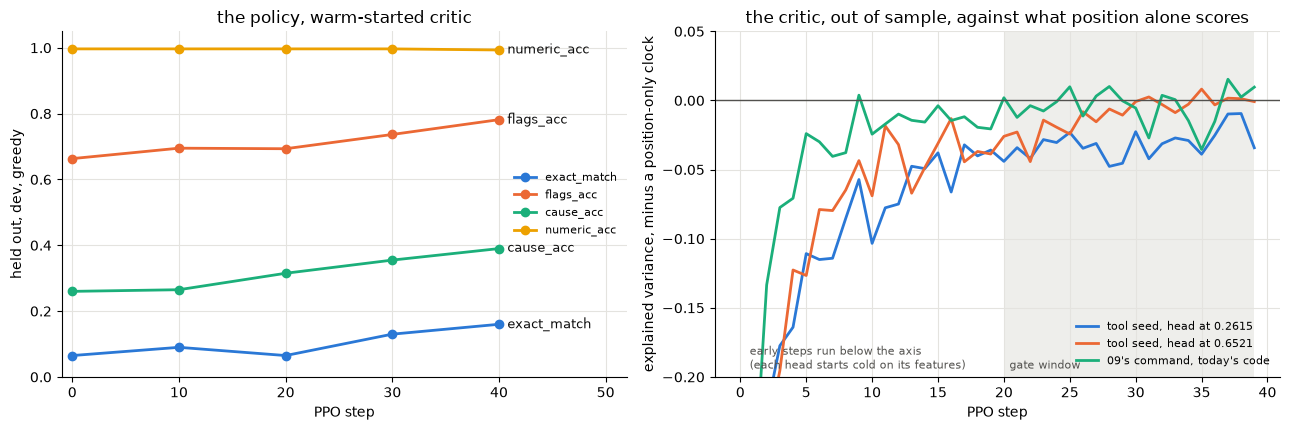

In [16]:
SERIES = ("#2a78d6", "#eb6834", "#1baf7a", "#eda100")   # reference palette, slots 1-4, in order
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
steps = [r["step"] for r in ev_warm]
for color, key in zip(SERIES, ("exact_match", "flags_acc", "cause_acc", "numeric_acc")):
    ys = [r[key] for r in ev_warm]
    ax1.plot(steps, ys, "-o", color=color, lw=2, ms=6, label=key)
    ax1.annotate(key, (steps[-1], ys[-1]), xytext=(6, 0), textcoords="offset points",
                 va="center", fontsize=9, color=INK)
ax1.set(xlabel="PPO step", ylabel="held out, dev, greedy", ylim=(0, 1.05),
        xlim=(-1, steps[-1] + 12), title="the policy, warm-started critic")
ax1.legend(loc="center right", fontsize=8, frameon=False)

for color, (label, name) in zip(SERIES, (("tool seed, head at 0.2615", "ppo-on-tool-seed-gate40"),
                                         ("tool seed, head at 0.6521", "ppo-on-tool-seed-warm-gate40"),
                                         ("09's command, today's code", "repro-09-current-code-40"))):
    me_r = load_run(name)[1]
    xs = [r["step"] for r in me_r if resid(r) is not None]
    ax2.plot(xs, [resid(r) for r in me_r if resid(r) is not None], color=color, lw=2, label=label)
ax2.axhline(0, color=MUTED, lw=1)
ax2.set_ylim(-0.2, 0.05)
ax2.axvspan(20, 39, color=GRID, alpha=0.6, lw=0)
ax2.annotate("gate window", (20, -0.2), xytext=(4, 6), textcoords="offset points", fontsize=8, color=MUTED)
ax2.annotate("early steps run below the axis\n(each head starts cold on its features)", (0.5, -0.2),
             xytext=(2, 6), textcoords="offset points", fontsize=8, color=MUTED)
ax2.set(xlabel="PPO step", ylabel="explained variance, minus a position-only clock",
        title="the critic, out of sample, against what position alone scores")
ax2.legend(loc="lower right", fontsize=8, frameon=False)
for ax in (ax1, ax2):
    ax.grid(color=GRID, lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(RUNS / "tool_seed_gate40.png", dpi=110)
plt.show()

## Where this leaves the tool line

**The calculator works, and the model is the one using it.** Held-out `numeric_acc` is
0.993-1.000 at all ten evaluation points of both runs, on a prompt that is v2's byte for byte,
with every episode making its three calls. That is the question this notebook was asked, and it
is answered.

**The per-step arithmetic gate failed once, on the corrected run.** Sampled at temperature 1.0,
three of 40 steps were imperfect: step 11 at 0.833 (one of eight episodes ran out of its
640-token budget, so its numbers were never written), step 16 at 0.958 (one call came back as an
error) and step 24 at 0.958 (one wrong number). The bar was >= 0.90 on every step, and step 11
is below it. Greedy decoding never shows this; sampling does, and sampling is what PPO trains on.

**The critic is where `09`'s is, and neither clears the bar as written.** Corrected, the tool
run is -0.0072 over steps 20-39 and -0.0008 over 30-39, against -0.0006 for `09`'s own command
on today's code. The first run's -0.031 was the warm start. What the corrected run does not
show is a critic that *beats* the clock, and nothing in this series has shown that inside 40
steps -- `11`'s was ahead on every step only from 75 on.

**The policy did not converge**, and was not run long enough to. `exact_match` 0.065 -> 0.160,
`flags_acc` 0.663 -> 0.782, `cause_acc` 0.260 -> 0.390 over 40 steps. Even converged, the severe
action (0 of 37 on dev) caps `exact_match` at 163/200 = 0.815 until the deferred dead-label
work is done.

### What `13` changes

The three calls are 72% of the policy's tokens and are paid nothing at the moment they are
made. `13` moves the numeric credit onto the calls themselves, scored by the harness as each
call returns, with a settlement where the JSON copies the number, so that the per-episode total
is still exactly `score(...).total`. That is one variable. A discount applied per turn rather
than per token is a second, and gets its own run. Swapping the harness for Qwen-Agent -- the
framework `membraneclaw-agent` is built on -- is a third, and comes after both, behind a gate
that its step-0 evaluation reproduce this notebook's G2 exactly.

`13`'s critic bar is set before it runs, from the measurement above rather than from zero:
over steps 20-39, no worse than `09`'s command on today's code (median >= -0.001), with the
in-sample fit above the clock.

### Postscript -- what `13` found

This configuration, run to 200 steps, peaked at `exact_match` **0.600** (step 125) and then
collapsed: the entropy bonus, averaged over episodes that are 72% call tokens, drove the calls off
their seed from step ~100, and every metric was 0.000 at step 200. The per-call credit above was
tried three ways and abandoned. With the bonus taken off the call tokens and qwen-agent as the
harness -- proven decoding-neutral case for case -- the same line ran 200 steps without collapsing,
`exact_match` 0.555 and rising. See `13_an_agent_harness_and_where_the_entropy_goes.ipynb`.